# CDC BRFSS Diabetes Analysis

Exploratory and statistical analysis of health, lifestyle and demographic
indicators associated with self-reported prediabetes/diabetes status in the 2015 CDC BRFSS dataset.

## 1. Dataset Overview

This project uses a curated version of the 2015 CDC Behavioral Risk Factor
Surveillance System (BRFSS) dataset containing 253,680 survey responses and
21 health, lifestyle and demographic predictors.

The target variable, `Diabetes_binary`, indicates self-reported prediabetes/diabetes status:

- `0` — no diabetes
- `1` — prediabetes/diabetes

The dataset is already cleaned and contains no missing values. The analysis
therefore focuses on class imbalance, exploratory analysis and statistical
associations rather than data cleaning.

**Note:** the target represents survey-reported prediabetes/diabetes status and should not be interpreted as a clinical diagnosis.

### 1.1 Imports & Feature Groups

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/diabetes_binary_health_indicators_BRFSS2015.csv")

TARGET = "Diabetes_binary"

ORDINAL_FEATURES = ["GenHlth", "Age", "Education", "Income"]

NOMINAL_FEATURES = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex"
]

QUANTITATIVE_FEATURES = ["BMI", "MentHlth", "PhysHlth"]

ALL_FEATURES = ORDINAL_FEATURES + NOMINAL_FEATURES + QUANTITATIVE_FEATURES

### 1.2 Load & Inspect

In [3]:
df = pd.read_csv(DATA_PATH).astype("int8")

print(f"Rows: {len(df):,}")
print(f"Predictors: {len(ALL_FEATURES)}")
print(f"Missing values: {df.isna().sum().sum():,}")

display(df.head())

Rows: 253,680
Predictors: 21
Missing values: 0


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


### 1.3 Target Distribution

In [4]:
target_distribution = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "No diabetes", 1: "Diabetes"})
    .to_frame("Count")
)

target_distribution["Percentage"] = target_distribution["Count"] / len(df) * 100

display(target_distribution.style.format({
    "Count": "{:,.0f}",
    "Percentage": "{:.2f}%"
}))

,Count,Percentage
Diabetes_binary,,
No diabetes,"218,334",86.07%
Diabetes,"35,346",13.93%


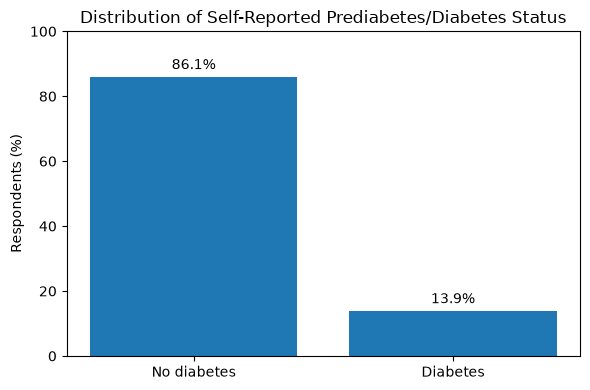

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(target_distribution.index, target_distribution["Percentage"])

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in target_distribution["Percentage"]
    ],
    padding=3
)

ax.set_title("Distribution of Self-Reported Prediabetes/Diabetes Status")
ax.set_ylabel("Respondents (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

The target is substantially imbalanced: approximately 86% of respondents are in
the no-diabetes class and 14% are in the prediabetes/diabetes class. This imbalance is important
when interpreting later model results because high overall accuracy can be achieved
while still performing poorly on the minority diabetes class.

## 2. Exploratory Data Analysis

Prediabetes/diabetes prevalence is explored across selected health, lifestyle and demographic
indicators. Because the target is imbalanced, prevalence within each feature group
is more informative than comparing raw diabetes counts.

### 2.1 Ordinal Features

In [17]:
def prevalence_by_group(data, feature):
    return (
        data.groupby(feature, observed=False)[TARGET]
        .mean()
        .mul(100)
        .reset_index(name="Prediabetes/diabetes prevalence")
    )

In [18]:
ORDINAL_LABELS = {
    "GenHlth": {
        1: "Excellent",
        2: "Very good",
        3: "Good",
        4: "Fair",
        5: "Poor"
    },
    "Age": {
        1: "18-24",
        2: "25-29",
        3: "30-34",
        4: "35-39",
        5: "40-44",
        6: "45-49",
        7: "50-54",
        8: "55-59",
        9: "60-64",
        10: "65-69",
        11: "70-74",
        12: "75-79",
        13: "80+"
    },
    "Education": {
        1: "None / kindergarten",
        2: "Grades 1-8",
        3: "Grades 9-11",
        4: "High school / GED",
        5: "Some college",
        6: "College graduate",
    },
    "Income": {
        1: "<$10k",
        2: "$10k-<$15k",
        3: "$15k-<$20k",
        4: "$20k-<$25k",
        5: "$25k-<$35k",
        6: "$35k-<$50k",
        7: "$50k-<$75k",
        8: "$75k+"
    }
}

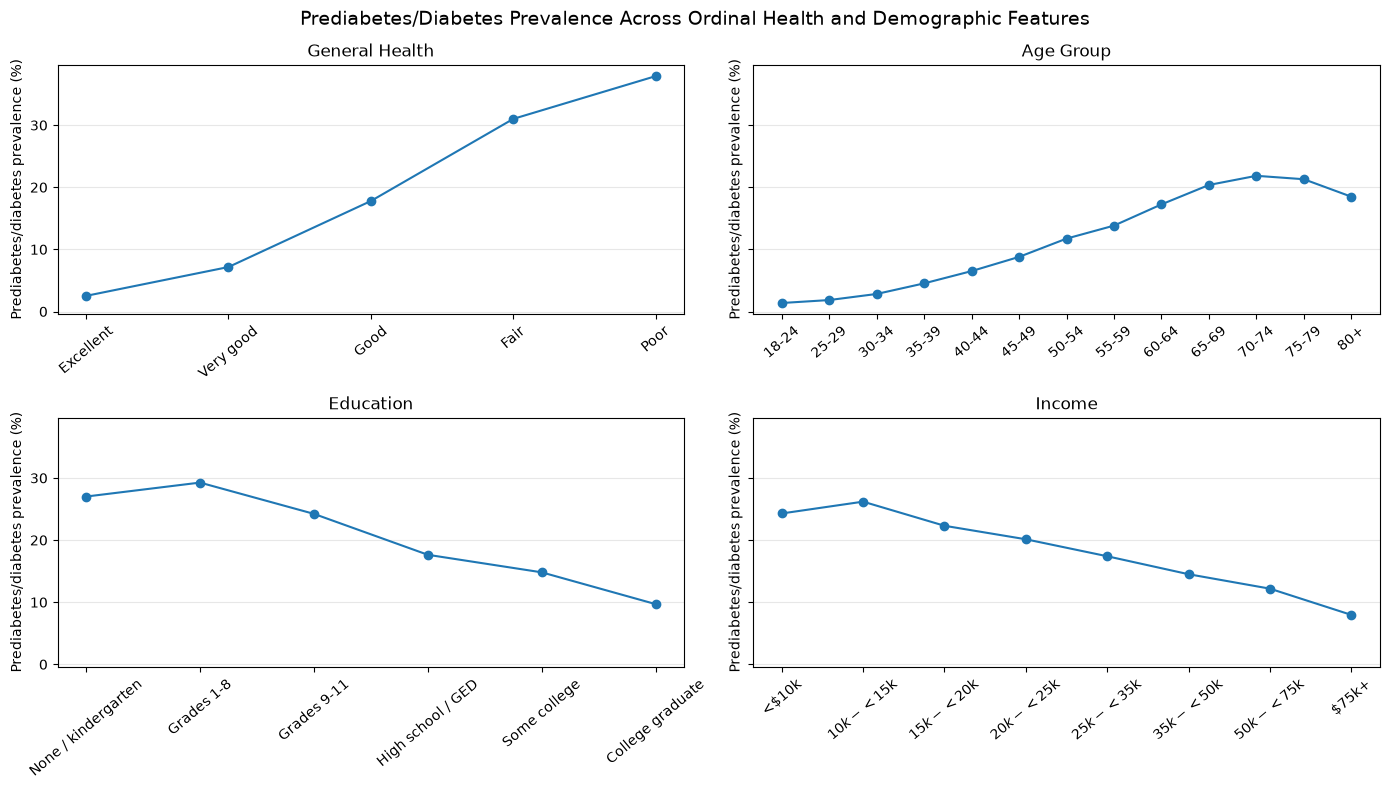

In [20]:
titles = {
    "GenHlth": "General Health",
    "Age": "Age Group",
    "Education": "Education",
    "Income": "Income"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

for feature, ax in zip(ORDINAL_FEATURES, axes.ravel()):
    summary = prevalence_by_group(df, feature)

    labels = [ORDINAL_LABELS[feature][value] for value in summary[feature]]

    ax.plot(labels, summary["Prediabetes/diabetes prevalence"], marker="o")

    ax.set_title(titles[feature])
    ax.set_ylabel("Prediabetes/diabetes prevalence (%)")
    ax.tick_params(axis="x", rotation=40)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Prediabetes/Diabetes Prevalence Across Ordinal Health and Demographic Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 2.2 Nominal Features

In [21]:
binary_results = []

for feature in NOMINAL_FEATURES:
    prevalence = df.groupby(feature)[TARGET].mean()

    binary_results.append({
        "Feature": feature,
        "Difference": (prevalence.loc[1] - prevalence.loc[0]) * 100
    })

binary_summary = pd.DataFrame(binary_results).sort_values("Difference")

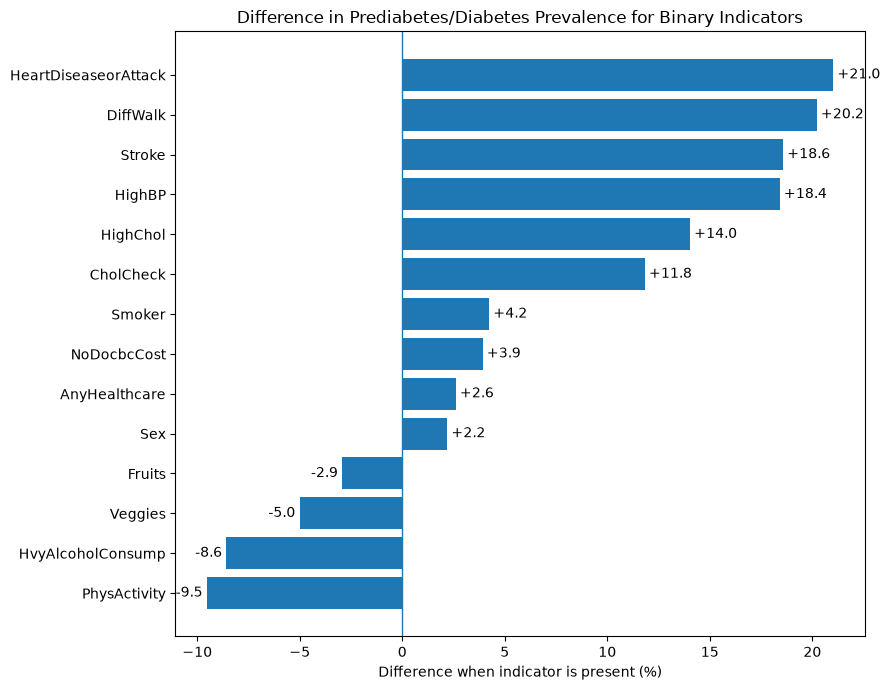

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(binary_summary["Feature"], binary_summary["Difference"])

ax.axvline(0, linewidth=1)

ax.bar_label(
    bars,
    labels=[
        f"{value:+.1f}"
        for value in binary_summary["Difference"]
    ],
    padding=3
)

ax.set_title("Difference in Prediabetes/Diabetes Prevalence for Binary Indicators")
ax.set_xlabel("Difference when indicator is present (%)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 2.3 Quantitative Features

In [ ]:
def plot_binned_prevalence(data, feature, bins, labels, title, ax):
    groups = pd.cut(data[feature], bins=bins, labels=labels, include_lowest=True)

    prevalence = data.groupby(groups, observed=False)[TARGET].mean().mul(100)

    bars = ax.bar(prevalence.index.astype(str), prevalence.values)

    ax.bar_label(
        bars,
        labels=[
            f"{value:.1f}%"
            for value in prevalence.values
        ],
        padding=3,
        fontsize=8
    )

    ax.set_title(title)
    ax.set_ylabel("Prediabetes/diabetes prevalence (%)")
    ax.tick_params(axis="x", rotation=35)

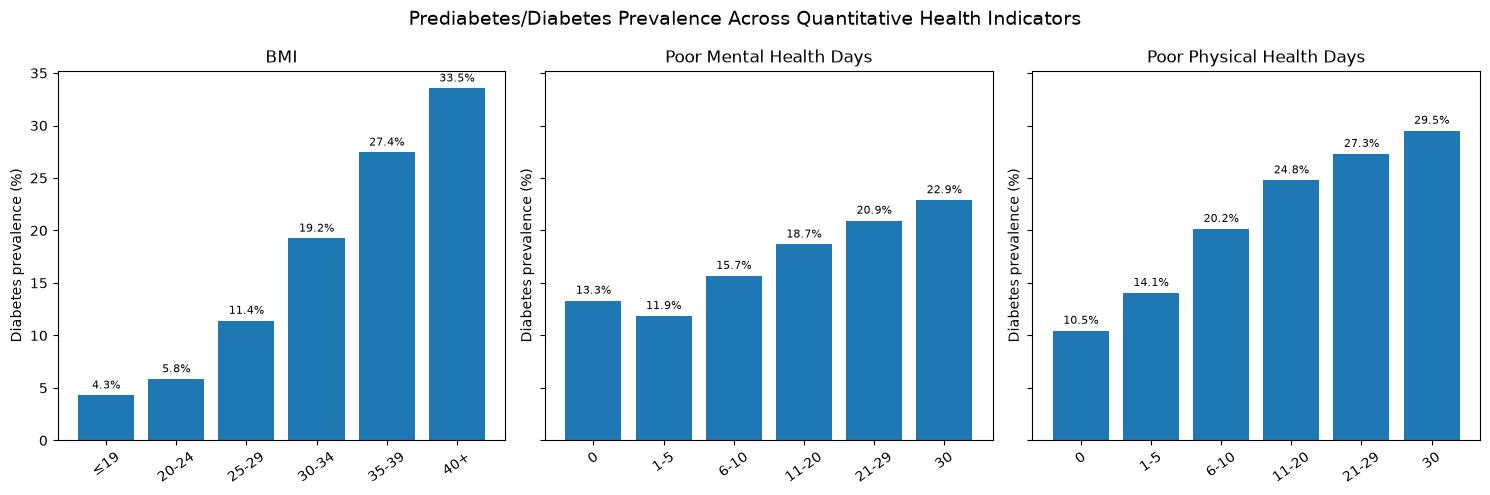

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

plot_binned_prevalence(
    df,
    "BMI",
    bins=[-np.inf, 19, 24, 29, 34, 39, np.inf],
    labels=["≤19", "20-24", "25-29", "30-34", "35-39", "40+"],
    title="BMI",
    ax=axes[0]
)

health_day_bins = [-1, 0, 5, 10, 20, 29, 30]
health_day_labels = ["0", "1-5", "6-10", "11-20", "21-29", "30"]

plot_binned_prevalence(
    df,
    "MentHlth",
    bins=health_day_bins,
    labels=health_day_labels,
    title="Poor Mental Health Days",
    ax=axes[1]
)

plot_binned_prevalence(
    df,
    "PhysHlth",
    bins=health_day_bins,
    labels=health_day_labels,
    title="Poor Physical Health Days",
    ax=axes[2]
)

plt.suptitle(
    "Prediabetes/Diabetes Prevalence Across Quantitative Health Indicators",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 2.4 EDA Findings

Several clear patterns are visible in the data. Prediabetes/diabetes prevalence increases
substantially as self-reported general health worsens and is generally higher
among older respondents. Lower income and education categories also show higher
observed prevalence.

Among binary indicators: high blood pressure, high cholesterol, difficulty
walking, stroke, and heart disease or heart attack are associated with notably
higher diabetes prevalence, while physical activity is associated with lower
observed prevalence.

BMI shows a particularly clear relationship with diabetes status, with prevalence
increasing across higher BMI bands. Poor physical health also shows a strong
pattern, while the relationship with poor mental health days is weaker.

## 3. Statistical Analysis

Statistical tests are used to quantify the relationships observed during EDA.

Different tests are used according to feature type:

- **Binary features:** Chi-square test of independence with Cramér's V
- **Ordinal features:** Spearman rank correlation
- **Quantitative features:** Mann–Whitney U test with rank-biserial correlation

Because the dataset contains more than 250,000 observations, even small effects can
produce very small p-values. Effect sizes are therefore emphasised alongside
statistical significance.

Benjamini–Hochberg correction is applied to account for multiple comparisons.

### 3.1 Imports & Helper Functions

In [26]:
from scipy.stats import (
    chi2_contingency,
    mannwhitneyu,
    spearmanr,
)
from statsmodels.stats.multitest import multipletests


def adjust_p_values(results):
    results = results.copy()

    results["Adjusted p-value"] = multipletests(results["p-value"], method="fdr_bh")[1]

    return results


def format_p_value(value):
    return "<1e-300" if value == 0 else f"{value:.2e}"

### 3.2 Binary Features

Chi-square tests assess whether each binary indicator is associated with diabetes
status. Cramér's V is reported as an effect size, where larger values indicate
stronger associations.

In [29]:
binary_results = []

for feature in NOMINAL_FEATURES:
    table = pd.crosstab(df[feature], df[TARGET])

    chi2, p_value, _, _ = chi2_contingency(table, correction=False)

    n = table.to_numpy().sum()

    cramers_v = np.sqrt(chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1)))

    binary_results.append({
        "Feature": feature,
        "Cramér's V": cramers_v,
        "p-value": p_value
    })

binary_results = (
    adjust_p_values(pd.DataFrame(binary_results))
    .sort_values("Cramér's V", ascending=False)
)

display(binary_results.style.format({
    "Cramér's V": "{:.3f}",
    "p-value": format_p_value,
    "Adjusted p-value": format_p_value
}).hide(axis="index"))

Feature,Cramér's V,p-value,Adjusted p-value
HighBP,0.263,<1e-300,<1e-300
DiffWalk,0.218,<1e-300,<1e-300
HighChol,0.200,<1e-300,<1e-300
HeartDiseaseorAttack,0.177,<1e-300,<1e-300
PhysActivity,0.118,<1e-300,<1e-300
Stroke,0.106,<1e-300,<1e-300
CholCheck,0.065,2.29e-233,4.58e-233
Smoker,0.061,7.24e-206,1.27e-205
HvyAlcoholConsump,0.057,1.30e-181,2.03e-181
Veggies,0.057,1.19e-178,1.66e-178


### 3.3 Ordinal Features

Spearman correlation is used for the ordered categorical features. The sign
indicates the direction of the relationship, while the magnitude indicates its
strength.

In [30]:
ordinal_results = []

for feature in ORDINAL_FEATURES:
    correlation, p_value = spearmanr(df[feature], df[TARGET])

    ordinal_results.append({
        "Feature": feature,
        "Spearman rho": correlation,
        "p-value": p_value,
    })

ordinal_results = adjust_p_values(pd.DataFrame(ordinal_results))

ordinal_results["Absolute rho"] = ordinal_results["Spearman rho"].abs()

ordinal_results = (
    ordinal_results
    .sort_values("Absolute rho", ascending=False)
    .drop(columns="Absolute rho")
)

display(
    ordinal_results.style.format({
        "Spearman rho": "{:+.3f}",
        "p-value": format_p_value,
        "Adjusted p-value": format_p_value,
    }).hide(axis="index")
)

Feature,Spearman rho,p-value,Adjusted p-value
GenHlth,+0.288,<1e-300,<1e-300
Age,+0.178,<1e-300,<1e-300
Income,-0.163,<1e-300,<1e-300
Education,-0.120,<1e-300,<1e-300


### 3.4 Quantitative Features

Mann–Whitney U tests compare the distributions of BMI, poor mental-health days and
poor physical-health days between respondents with and without diabetes.

Rank-biserial correlation is included as an effect size; positive values indicate
that the diabetes group tends to have higher values.

In [31]:
quantitative_results = []

no_diabetes = df[df[TARGET] == 0]
diabetes = df[df[TARGET] == 1]

for feature in QUANTITATIVE_FEATURES:
    group_0 = no_diabetes[feature]
    group_1 = diabetes[feature]

    u_statistic, p_value = mannwhitneyu(group_1, group_0, alternative="two-sided")

    rank_biserial = 2 * u_statistic / (len(group_1) * len(group_0)) - 1

    quantitative_results.append({
        "Feature": feature,
        "Median: no diabetes": group_0.median(),
        "Median: diabetes": group_1.median(),
        "Rank-biserial": rank_biserial,
        "p-value": p_value,
    })

quantitative_results = adjust_p_values(pd.DataFrame(quantitative_results))

quantitative_results["Absolute effect"] = (quantitative_results["Rank-biserial"].abs())

quantitative_results = (
    quantitative_results
    .sort_values("Absolute effect", ascending=False)
    .drop(columns="Absolute effect")
)

display(quantitative_results.style.format({
    "Median: no diabetes": "{:.1f}",
    "Median: diabetes": "{:.1f}",
    "Rank-biserial": "{:+.3f}",
    "p-value": format_p_value,
    "Adjusted p-value": format_p_value,
}).hide(axis="index"))

Feature,Median: no diabetes,Median: diabetes,Rank-biserial,p-value,Adjusted p-value
BMI,27.0,31.0,+0.377,<1e-300,<1e-300
PhysHlth,0.0,1.0,+0.226,<1e-300,<1e-300
MentHlth,0.0,0.0,+0.055,1.75e-90,1.75e-90


### 3.5 Statistical Findings

Most features show statistically significant associations with self-reported
prediabetes/diabetes status. Given the very large sample size, statistical significance alone
is not particularly informative, so greater attention is given to effect sizes.

Among the binary indicators: high blood pressure, difficulty walking, high
cholesterol and a history of heart disease or heart attack show some of the
strongest associations with prediabetes/diabetes status.

General health shows the strongest ordinal relationship, with worse self-reported
health associated with higher diabetes prevalence. Older age categories are also
positively associated with diabetes, while higher income and education categories
show negative associations.

Among the quantitative variables, BMI shows the clearest separation between the
two groups, followed by poor physical-health days. Poor mental-health days show a
much weaker association.

These are univariate associations and should not be interpreted as causal effects.
Relationships between predictors may overlap or be influenced by other health and
demographic factors.

## 4. Findings and Limitations

### Key Findings

The analysis identified several clear relationships between the BRFSS health
indicators and self-reported prediabetes/diabetes status:

- Diabetes prevalence increases considerably as self-reported general health
  worsens and is generally higher among older respondents.
- High blood pressure, high cholesterol, difficulty walking, and a history of
  heart disease or heart attack show some of the strongest binary associations
  with diabetes.
- BMI shows the strongest relationship among the quantitative features, with
  diabetes prevalence increasing noticeably across higher BMI ranges.
- Poor physical health is also associated with diabetes, while poor mental-health
  days show a much weaker relationship.
- Higher income and education categories are associated with lower observed
  diabetes prevalence.

The statistical analysis supports the patterns observed during EDA. However, the
large sample size means that even weak relationships can be statistically
significant, so effect sizes are more informative than p-values alone.

### Limitations

Several limitations should be considered when interpreting these results:

- **Self-reported data:** BRFSS responses rely on participants accurately reporting
  their health status, behaviours, and diagnosed diabetes.
- **Observational data:** The analysis identifies associations rather than causal
  relationships. For example, an association between physical activity and lower
  diabetes prevalence does not demonstrate that physical activity alone caused
  the difference.
- **Univariate analysis:** Most statistical tests examine one predictor at a time.
  Health, demographic, and socioeconomic variables are related to one another, so
  some observed associations may overlap or be influenced by other factors.
- **Class imbalance:** Only around 14% of respondents belong to the diabetes class,
  which creates additional challenges when evaluating predictive models.
- **Dataset age:** The data comes from the 2015 BRFSS survey, so the relationships
  observed here may not fully reflect more recent population health patterns.

### Conclusion

Overall, the dataset contains meaningful relationships between self-reported
prediabetes/diabetes status and several health, lifestyle, and demographic indicators.
General health, blood pressure, BMI, cardiovascular conditions, and physical
health show particularly notable associations.